<a href="https://colab.research.google.com/github/ShubhGuPTA-cmd/ML-experiments/blob/main/LAB_5_1%5BSVM%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()   # choose non_linear_separable_dataset.csv

Saving non_linear_separable_dataset.csv to non_linear_separable_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("/content/non_linear_separable_dataset.csv")
print("Shape:", df.shape)
print(df.head())
print(df["Class"].value_counts())

Shape: (200, 3)
   Feature1  Feature2  Class
0 -3.501840  4.878339      0
1 -1.197143  4.100531      0
2 -2.072024  4.757996      0
3 -2.605366  4.579309      0
4 -4.375925  3.391600      0
Class
0    100
1    100
Name: count, dtype: int64


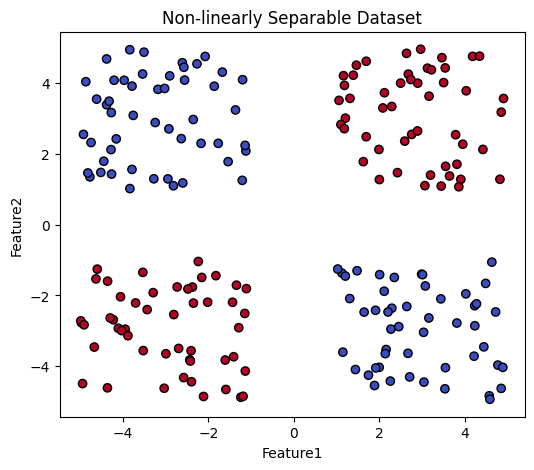

In [ ]:
X = df[["Feature1", "Feature2"]].values
y = df["Class"].values

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Non-linearly Separable Dataset")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (160, 2) Test: (40, 2)


In [ ]:
models = {
    "Linear": SVC(kernel="linear", C=1.0),
    "Polynomial": SVC(kernel="poly", degree=3, C=1.0),
    "RBF": SVC(kernel="rbf", C=1.0, gamma="scale"),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name:10s} | Train: {model.score(X_train, y_train):.4f} | "
          f"Test: {model.score(X_test, y_test):.4f} | "
          f"Support vectors: {len(model.support_vectors_)}")

Linear     | Train: 0.7562 | Test: 0.6500 | Support vectors: 152
Polynomial | Train: 0.6312 | Test: 0.5000 | Support vectors: 153
RBF        | Train: 1.0000 | Test: 1.0000 | Support vectors: 29


In [ ]:
clf = models["RBF"]
y_pred = clf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy: 1.0
Confusion matrix:
 [[20  0]
 [ 0 20]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



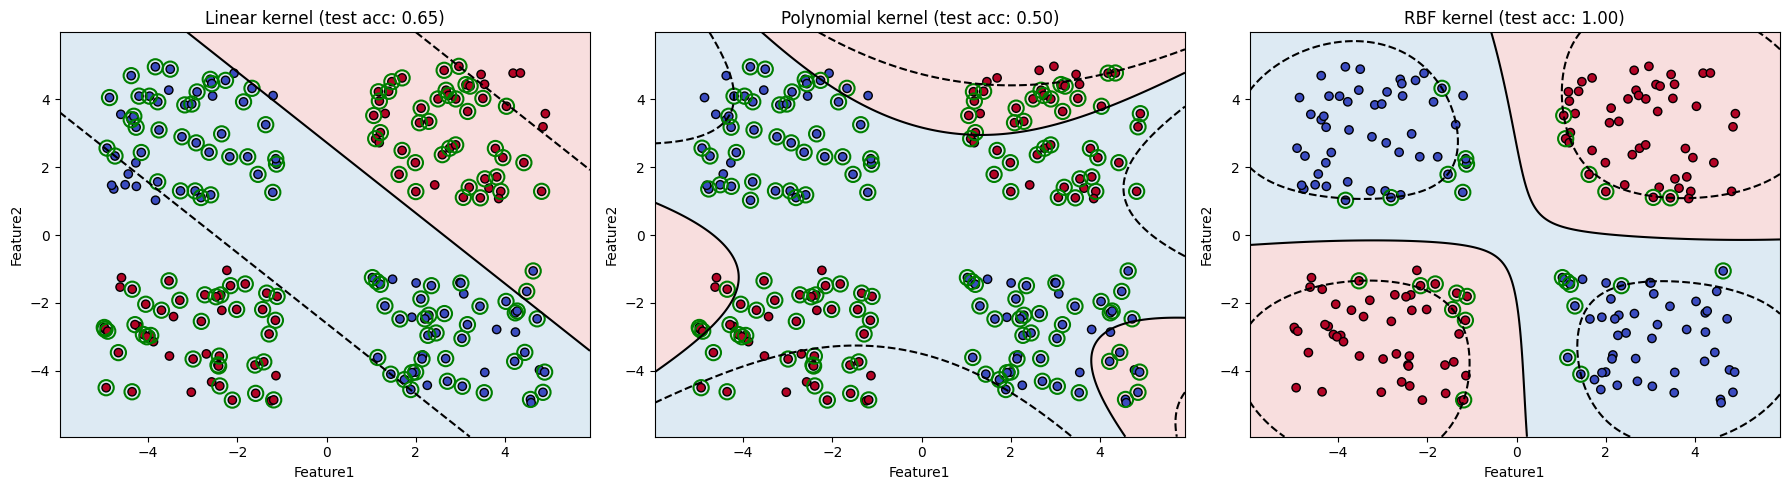

In [ ]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.15, colors=["tab:blue", "tab:red"])
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=120, facecolors="none", edgecolors="g", linewidths=1.5)
    ax.set_title(f"{name} kernel (test acc: {model.score(X_test, y_test):.2f})")
    ax.set_xlabel("Feature1")
    ax.set_ylabel("Feature2")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1, 1]}
grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score  :", grid.best_score_)
print("Test accuracy  :", grid.score(X_test, y_test))

Best parameters: {'C': 0.1, 'gamma': 'scale'}
Best CV score  : 1.0
Test accuracy  : 1.0
